# The Accuracy-Transparency Trade-Off in Responsible AI

**Module:** Governing Intelligent Systems for Sustainability
**Dataset:** UCI Adult Census Income (48,842 rows) - a high-stakes income
prediction task analogous to credit or hiring decisions.

## Research Questions
1. **RQ1** - How large is the predictive performance gap between inherently
   interpretable models (logistic regression, shallow decision tree) and
   black-box ensembles (random forest, gradient boosting)?
2. **RQ2** - How does performance scale with model complexity, and at what
   point do additional complexity and reduced transparency stop yielding
   meaningful accuracy gains?
3. **RQ3** - Do transparent and black-box models attribute their predictions
   to the same features, and how strongly do their importance rankings agree?
4. **RQ4** - Does the accuracy advantage of black-box models hold uniformly
   across demographic subgroups (sex, race)?
5. **RQ5** - How faithfully can a black-box model be approximated by a compact
   interpretable surrogate (distilled decision tree)?

**Reproducibility:** pure scikit-learn, every random component seeded
(SEED=42). Each RQ produces one figure (saved as vector PDF) and one result
table (saved as CSV) under `outputs/`.

**Data access on Kaggle:** attach the *Adult Census Income* (uciml) dataset,
or enable Internet in notebook settings so the OpenML fallback can download it.


In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

SEED = 42
FIG_DIR = os.path.join("outputs", "figures")
TAB_DIR = os.path.join("outputs", "tables")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

# Poster-quality plot defaults: vector PDF output, readable fonts, no chartjunk
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "pdf.fonttype": 42,          # keep text editable/selectable in PDF
    "figure.constrained_layout.use": True,
})

# Colorblind-safe palette: cool = interpretable, warm = black-box
C_LR, C_DT, C_RF, C_GB = "#0173B2", "#029E73", "#CC78BC", "#D55E00"


def save_fig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, name + ".pdf"))
    fig.savefig(os.path.join(FIG_DIR, name + ".png"), dpi=300)
    plt.show()
    print(f"  saved figure: {name}.pdf / .png")


def save_table(df, name):
    df.to_csv(os.path.join(TAB_DIR, name + ".csv"), index=False)
    print(f"  saved table:  {name}.csv")

## 1. Data loading and preprocessing

- `fnlwgt` is dropped (census sampling weight, not a person-level attribute);
  `education` is dropped because it duplicates `education-num` as text.
- Missing categorical values become an explicit `Missing` category, then
  one-hot encoding; numeric features are standardized.
- All preprocessing lives inside a `Pipeline`, so it is fit on training folds
  only - no data leakage into validation or test scores.
- Stratified 80/20 train/test split keeps the class ratio identical on both
  sides.

In [2]:
print("Loading Adult Census Income dataset...")

KAGGLE_CSV = "/kaggle/input/adult-census-income/adult.csv"
if os.path.exists(KAGGLE_CSV):
    raw = pd.read_csv(KAGGLE_CSV).replace("?", np.nan)
    raw = raw.rename(columns={"education.num": "education-num",
                              "marital.status": "marital-status",
                              "capital.gain": "capital-gain",
                              "capital.loss": "capital-loss",
                              "hours.per.week": "hours-per-week",
                              "native.country": "native-country",
                              "income": "class"})
else:
    raw = fetch_openml("adult", version=2, as_frame=True).frame

# fnlwgt is a census sampling weight (not a person-level attribute) and
# education duplicates education-num as text -> both dropped
df = raw.drop(columns=["fnlwgt", "education"])
y = (df.pop("class").astype(str).str.strip() == ">50K").astype(int)

CAT_COLS = ["workclass", "marital-status", "occupation", "relationship",
            "race", "sex", "native-country"]
NUM_COLS = ["age", "education-num", "capital-gain", "capital-loss",
            "hours-per-week"]
X = df[CAT_COLS + NUM_COLS].copy()
X[CAT_COLS] = X[CAT_COLS].astype(object)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f"  {len(X_train)} train / {len(X_test)} test rows, "
      f"positive rate = {y.mean():.3f}")

preprocess = ColumnTransformer([
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), CAT_COLS),
    ("num", StandardScaler(), NUM_COLS),
])


def make_pipe(model):
    return Pipeline([("prep", preprocess), ("model", model)])


# Interpretable models (cool colors) vs black-box ensembles (warm colors)
MODELS = {
    "Logistic Regression": (make_pipe(LogisticRegression(max_iter=1000,
                                                         random_state=SEED)),
                            "interpretable", C_LR),
    "Decision Tree (depth 4)": (make_pipe(DecisionTreeClassifier(max_depth=4,
                                                                 random_state=SEED)),
                                "interpretable", C_DT),
    "Random Forest": (make_pipe(RandomForestClassifier(n_estimators=300,
                                                       random_state=SEED)),
                      "black-box", C_RF),
    "Gradient Boosting": (make_pipe(HistGradientBoostingClassifier(random_state=SEED)),
                          "black-box", C_GB),
}

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def n_decision_units(name, pipe):
    """Complexity proxy: how many learned units (weights or tree leaves) a
    human must inspect to fully understand the model."""
    m = pipe.named_steps["model"]
    if name == "Logistic Regression":
        return m.coef_.size
    if name.startswith("Decision Tree"):
        return int(m.tree_.n_leaves)
    if name == "Random Forest":
        return int(sum(e.tree_.n_leaves for e in m.estimators_))
    try:  # HistGradientBoosting: count leaves over all boosting stages
        return int(sum(p.get_n_leaf_nodes()
                       for stage in m._predictors for p in stage))
    except AttributeError:
        return int(m.n_iter_ * m.max_leaf_nodes)

Loading Adult Census Income dataset...
  39073 train / 9769 test rows, positive rate = 0.239


## RQ1 - Performance gap between interpretable and black-box models

Four models are compared with 5-fold stratified CV (model stability) plus one
held-out test set (final numbers). As a transparency axis we count
**decision units**: the number of learned elements a human must inspect to
fully understand the model (coefficients for logistic regression, leaves for
tree-based models).

**Outputs:** `rq1_model_performance.csv`,
`rq1_accuracy_transparency_pareto.pdf`


RQ1: model comparison (5-fold CV + held-out test)...


  Logistic Regression        test AUC=0.9049 acc=0.8554 units=91


  Decision Tree (depth 4)    test AUC=0.8743 acc=0.8455 units=16


  Random Forest              test AUC=0.8973 acc=0.8518 units=2013240


  Gradient Boosting          test AUC=0.9297 acc=0.8750 units=2635
  saved table:  rq1_model_performance.csv


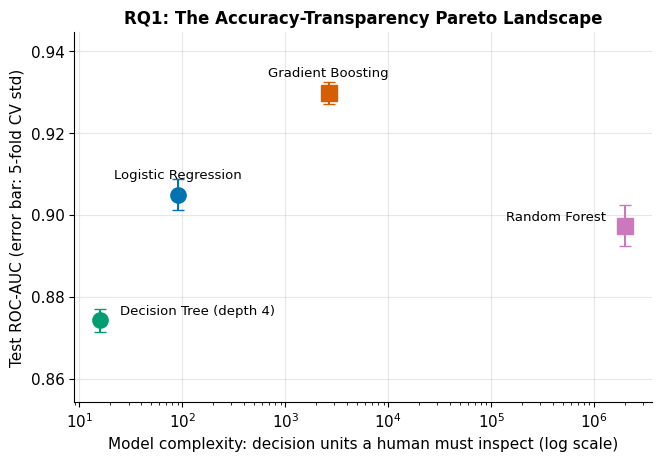

  saved figure: rq1_accuracy_transparency_pareto.pdf / .png


In [3]:
print("\nRQ1: model comparison (5-fold CV + held-out test)...")
rows = []
fitted = {}
for name, (pipe, category, color) in MODELS.items():
    cv_res = cross_validate(pipe, X_train, y_train, cv=CV,
                            scoring=["accuracy", "f1", "roc_auc"], n_jobs=-1)
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0
    fitted[name] = pipe
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    rows.append({
        "model": name,
        "category": category,
        "cv_accuracy_mean": cv_res["test_accuracy"].mean(),
        "cv_accuracy_std": cv_res["test_accuracy"].std(),
        "cv_f1_mean": cv_res["test_f1"].mean(),
        "cv_f1_std": cv_res["test_f1"].std(),
        "cv_auc_mean": cv_res["test_roc_auc"].mean(),
        "cv_auc_std": cv_res["test_roc_auc"].std(),
        "test_accuracy": accuracy_score(y_test, pred),
        "test_f1": f1_score(y_test, pred),
        "test_auc": roc_auc_score(y_test, proba),
        "fit_time_s": fit_time,
        "n_decision_units": n_decision_units(name, pipe),
    })
    print(f"  {name:26s} test AUC={rows[-1]['test_auc']:.4f} "
          f"acc={rows[-1]['test_accuracy']:.4f} units={rows[-1]['n_decision_units']}")

rq1 = pd.DataFrame(rows).round(4)
save_table(rq1, "rq1_model_performance")

# Per-model label offsets so annotations stay clear of axes and edges
LABEL_POS = {"Logistic Regression": ((0, 12), "center"),
             "Decision Tree (depth 4)": ((14, 4), "left"),
             "Random Forest": ((-14, 4), "right"),
             "Gradient Boosting": ((0, 12), "center")}
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for _, r in rq1.iterrows():
    color = MODELS[r["model"]][2]
    marker = "o" if r["category"] == "interpretable" else "s"
    ax.errorbar(r["n_decision_units"], r["test_auc"], yerr=r["cv_auc_std"],
                fmt=marker, ms=11, color=color, capsize=4, lw=1.5)
    offset, ha = LABEL_POS[r["model"]]
    ax.annotate(r["model"], (r["n_decision_units"], r["test_auc"]),
                textcoords="offset points", xytext=offset, ha=ha,
                fontsize=9.5)
ax.set_xscale("log")
ax.set_xlabel("Model complexity: decision units a human must inspect (log scale)")
ax.set_ylabel("Test ROC-AUC (error bar: 5-fold CV std)")
ax.set_title("RQ1: The Accuracy-Transparency Pareto Landscape")
ax.set_ylim(rq1["test_auc"].min() - 0.02, rq1["test_auc"].max() + 0.015)
save_fig(fig, "rq1_accuracy_transparency_pareto")

In [4]:
# RQ1 result table (saved as outputs/tables/rq1_model_performance.csv)
rq1.round(4)

,model,category,cv_accuracy_mean,cv_accuracy_std,cv_f1_mean,cv_f1_std,cv_auc_mean,cv_auc_std,test_accuracy,test_f1,test_auc,fit_time_s,n_decision_units
0,Logistic Regression,interpretable,0.8514,0.0049,0.6591,0.0097,0.9064,0.0038,0.8554,0.6649,0.9049,0.3074,91
1,Decision Tree (depth 4),interpretable,0.8427,0.0038,0.6174,0.0133,0.8768,0.0028,0.8455,0.6269,0.8743,0.0771,16
2,Random Forest,black-box,0.8469,0.0026,0.6578,0.0063,0.8938,0.0050,0.8518,0.6650,0.8973,4.8808,2013240
3,Gradient Boosting,black-box,0.8720,0.0043,0.7089,0.0087,0.9279,0.0026,0.8750,0.7139,0.9297,1.4736,2635


## RQ2 - Diminishing returns of complexity

A single decision tree is swept over `max_depth` 1-20 with 5-fold CV. The
*sweet spot* is the smallest depth whose CV AUC is within 0.002 of the best -
beyond it, extra complexity buys no meaningful accuracy while transparency
keeps degrading.

**Outputs:** `rq2_complexity_sweep.csv`, `rq2_complexity_sweep.pdf`


RQ2: decision-tree depth sweep...


  saved table:  rq2_complexity_sweep.csv
  sweet spot: depth=8 (CV AUC 0.9018, best 0.9021)


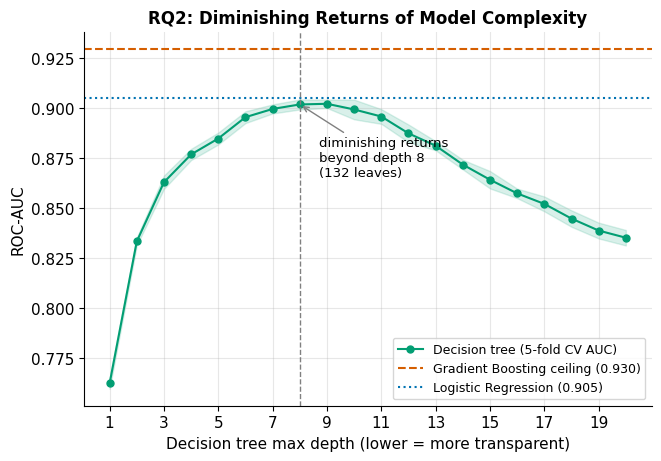

  saved figure: rq2_complexity_sweep.pdf / .png


In [5]:
print("\nRQ2: decision-tree depth sweep...")
depths = list(range(1, 21))
sweep = []
for d in depths:
    pipe = make_pipe(DecisionTreeClassifier(max_depth=d, random_state=SEED))
    cv_res = cross_validate(pipe, X_train, y_train, cv=CV,
                            scoring="roc_auc", n_jobs=-1)
    pipe.fit(X_train, y_train)
    sweep.append({
        "max_depth": d,
        "cv_auc_mean": cv_res["test_score"].mean(),
        "cv_auc_std": cv_res["test_score"].std(),
        "test_auc": roc_auc_score(y_test,
                                  pipe.predict_proba(X_test)[:, 1]),
        "n_leaves": int(pipe.named_steps["model"].tree_.n_leaves),
    })
rq2 = pd.DataFrame(sweep)

# Sweet spot: smallest depth within 0.002 AUC of the best CV mean
best = rq2["cv_auc_mean"].max()
sweet = rq2[rq2["cv_auc_mean"] >= best - 0.002].iloc[0]
rq2["is_sweet_spot"] = rq2["max_depth"] == sweet["max_depth"]
save_table(rq2.round(4), "rq2_complexity_sweep")
print(f"  sweet spot: depth={int(sweet['max_depth'])} "
      f"(CV AUC {sweet['cv_auc_mean']:.4f}, best {best:.4f})")

lr_auc = rq1.loc[rq1["model"] == "Logistic Regression", "test_auc"].iloc[0]
gb_auc = rq1.loc[rq1["model"] == "Gradient Boosting", "test_auc"].iloc[0]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(rq2["max_depth"], rq2["cv_auc_mean"], "-o", color=C_DT, ms=5,
        label="Decision tree (5-fold CV AUC)")
ax.fill_between(rq2["max_depth"],
                rq2["cv_auc_mean"] - rq2["cv_auc_std"],
                rq2["cv_auc_mean"] + rq2["cv_auc_std"],
                color=C_DT, alpha=0.15)
ax.axhline(gb_auc, color=C_GB, ls="--", lw=1.5,
           label=f"Gradient Boosting ceiling ({gb_auc:.3f})")
ax.axhline(lr_auc, color=C_LR, ls=":", lw=1.5,
           label=f"Logistic Regression ({lr_auc:.3f})")
ax.axvline(sweet["max_depth"], color="gray", ls="--", lw=1)
ax.annotate(f"diminishing returns\nbeyond depth {int(sweet['max_depth'])}\n"
            f"({int(sweet['n_leaves'])} leaves)",
            (sweet["max_depth"], sweet["cv_auc_mean"]),
            textcoords="offset points", xytext=(14, -52), fontsize=9.5,
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_xlabel("Decision tree max depth (lower = more transparent)")
ax.set_ylabel("ROC-AUC")
ax.set_title("RQ2: Diminishing Returns of Model Complexity")
ax.set_xticks(depths[::2])
ax.legend(loc="lower right", fontsize=9)
save_fig(fig, "rq2_complexity_sweep")

In [6]:
# RQ2 result table (saved as outputs/tables/rq2_complexity_sweep.csv)
rq2.round(4)

,max_depth,cv_auc_mean,cv_auc_std,test_auc,n_leaves,is_sweet_spot
0,1,0.7622,0.0026,0.7528,2,False
1,2,0.8332,0.0019,0.8316,4,False
2,3,0.8629,0.0033,0.8602,8,False
3,4,0.8768,0.0028,0.8743,16,False
4,5,0.8848,0.0030,0.8847,30,False
5,6,0.8954,0.0029,0.8977,52,False
6,7,0.8996,0.0023,0.9024,87,False
7,8,0.9018,0.0025,0.9031,132,True
8,9,0.9021,0.0021,0.9043,195,False
9,10,0.8993,0.0049,0.9047,293,False


## RQ3 - Do the models rely on the same features?

Permutation importance (10 repeats, ROC-AUC drop) is computed for **both**
models with the **same attribution method**, so the comparison measures model
behaviour rather than differences between explanation techniques. Agreement is
quantified with Spearman rank correlation across all 12 features.

**Outputs:** `rq3_feature_importance_agreement.csv`,
`rq3_feature_importance_agreement.pdf`


RQ3: permutation feature importance (10 repeats each)...


  saved table:  rq3_feature_importance_agreement.csv
  Spearman rank correlation = 0.839 (p=0.0006)


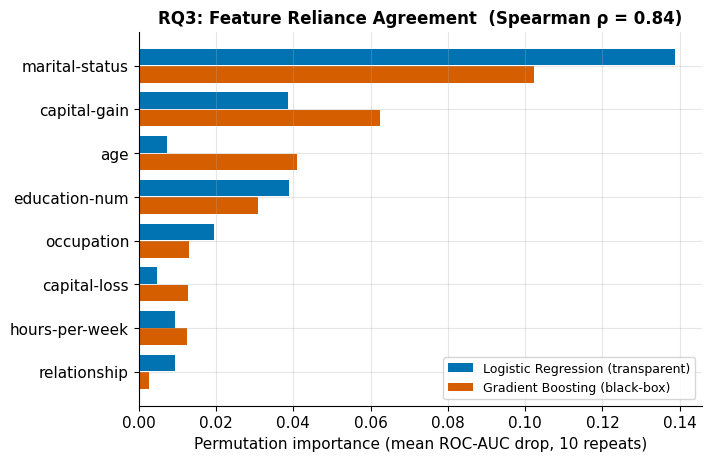

  saved figure: rq3_feature_importance_agreement.pdf / .png


In [7]:
print("\nRQ3: permutation feature importance (10 repeats each)...")
imp = {}
for name in ["Logistic Regression", "Gradient Boosting"]:
    res = permutation_importance(fitted[name], X_test, y_test,
                                 scoring="roc_auc", n_repeats=10,
                                 random_state=SEED, n_jobs=-1)
    imp[name] = pd.Series(res.importances_mean, index=X.columns)

rho, pval = spearmanr(imp["Logistic Regression"], imp["Gradient Boosting"])
rq3 = pd.DataFrame({
    "feature": X.columns,
    "importance_logreg": imp["Logistic Regression"].values,
    "rank_logreg": imp["Logistic Regression"].rank(ascending=False).astype(int).values,
    "importance_gb": imp["Gradient Boosting"].values,
    "rank_gb": imp["Gradient Boosting"].rank(ascending=False).astype(int).values,
}).sort_values("importance_gb", ascending=False)
rq3["spearman_rho_all_features"] = round(rho, 4)
save_table(rq3.round(4), "rq3_feature_importance_agreement")
print(f"  Spearman rank correlation = {rho:.3f} (p={pval:.4f})")

top = rq3.head(8).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 4.5))
ypos = np.arange(len(top))
ax.barh(ypos + 0.2, top["importance_logreg"], height=0.38, color=C_LR,
        label="Logistic Regression (transparent)")
ax.barh(ypos - 0.2, top["importance_gb"], height=0.38, color=C_GB,
        label="Gradient Boosting (black-box)")
ax.set_yticks(ypos)
ax.set_yticklabels(top["feature"])
ax.set_xlabel("Permutation importance (mean ROC-AUC drop, 10 repeats)")
ax.set_title(f"RQ3: Feature Reliance Agreement  (Spearman ρ = {rho:.2f})")
ax.legend(fontsize=9, loc="lower right")
save_fig(fig, "rq3_feature_importance_agreement")

In [8]:
# RQ3 result table (saved as outputs/tables/rq3_feature_importance_agreement.csv)
rq3.round(4)

,feature,importance_logreg,rank_logreg,importance_gb,rank_gb,spearman_rho_all_features
1,marital-status,0.1387,1,0.1022,1,0.8392
9,capital-gain,0.0385,3,0.0625,2,0.8392
7,age,0.0072,7,0.0409,3,0.8392
8,education-num,0.0388,2,0.0309,4,0.8392
2,occupation,0.0195,4,0.0130,5,0.8392
10,capital-loss,0.0048,9,0.0127,6,0.8392
11,hours-per-week,0.0094,6,0.0125,7,0.8392
3,relationship,0.0094,5,0.0028,8,0.8392
0,workclass,0.0023,10,0.0024,9,0.8392
5,sex,0.0069,8,0.0014,10,0.8392


## RQ4 - The fairness dimension

The held-out test set is sliced by `sex` and `race`; per-subgroup ROC-AUC is
computed for the transparent and the black-box model. If the black-box
advantage differs across groups, the cost of choosing transparency is not paid
equally - a governance concern, not just a technical one.

**Outputs:** `rq4_subgroup_performance.csv`, `rq4_subgroup_fairness.pdf`


RQ4: subgroup analysis...


  saved table:  rq4_subgroup_performance.csv
attribute              group  n_test  auc_logreg  auc_gb  blackbox_advantage
  overall                All    9769      0.9049  0.9297              0.0248
      sex             Female    3259      0.9291  0.9475              0.0184
      sex               Male    6510      0.8811  0.9121              0.0310
     race              Black     968      0.9275  0.9557              0.0281
     race              White    8312      0.9014  0.9267              0.0253
     race Asian-Pac-Islander     311      0.8812  0.8989              0.0177
     race              Other      82      0.9389  0.9722              0.0333
     race Amer-Indian-Eskimo      96      0.8962  0.9212              0.0250


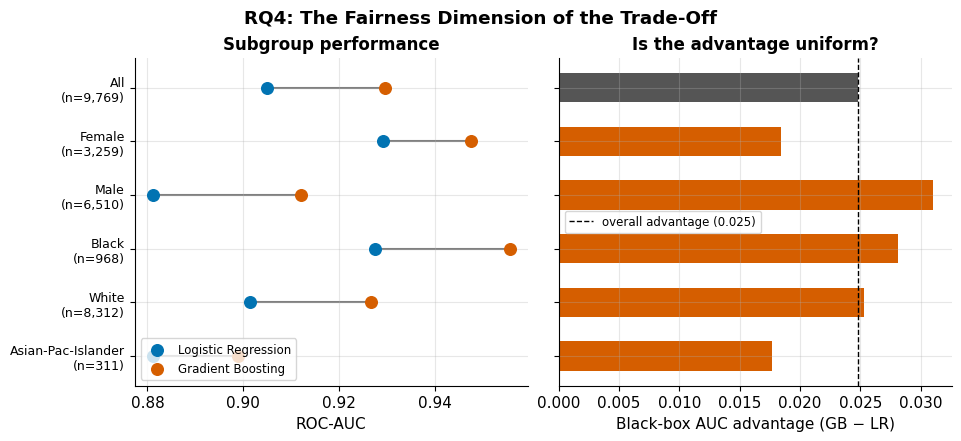

  saved figure: rq4_subgroup_fairness.pdf / .png


In [9]:
print("\nRQ4: subgroup analysis...")
proba_lr = fitted["Logistic Regression"].predict_proba(X_test)[:, 1]
proba_gb = fitted["Gradient Boosting"].predict_proba(X_test)[:, 1]

groups = [("overall", "All", np.ones(len(X_test), dtype=bool))]
for attr in ["sex", "race"]:
    for val in X_test[attr].dropna().unique():
        groups.append((attr, str(val), (X_test[attr] == val).values))

rows = []
for attr, val, mask in groups:
    if mask.sum() < 30 or y_test[mask].nunique() < 2:
        continue
    auc_lr = roc_auc_score(y_test[mask], proba_lr[mask])
    auc_gb = roc_auc_score(y_test[mask], proba_gb[mask])
    rows.append({"attribute": attr, "group": val, "n_test": int(mask.sum()),
                 "positive_rate": y_test[mask].mean(),
                 "auc_logreg": auc_lr, "auc_gb": auc_gb,
                 "blackbox_advantage": auc_gb - auc_lr})
rq4 = pd.DataFrame(rows)
save_table(rq4.round(4), "rq4_subgroup_performance")
print(rq4[["attribute", "group", "n_test", "auc_logreg", "auc_gb",
           "blackbox_advantage"]].round(4).to_string(index=False))

plot4 = rq4[(rq4["attribute"] == "overall") | (rq4["n_test"] >= 150)]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.3), sharey=True)
ypos = np.arange(len(plot4))[::-1]
labels = [f"{g}\n(n={n:,})" for g, n in zip(plot4["group"], plot4["n_test"])]
for yp, (_, r) in zip(ypos, plot4.iterrows()):
    ax1.plot([r["auc_logreg"], r["auc_gb"]], [yp, yp], color="gray",
             lw=1.5, zorder=1)
ax1.scatter(plot4["auc_logreg"], ypos, s=70, color=C_LR, zorder=2,
            label="Logistic Regression")
ax1.scatter(plot4["auc_gb"], ypos, s=70, color=C_GB, zorder=2,
            label="Gradient Boosting")
ax1.set_yticks(ypos)
ax1.set_yticklabels(labels, fontsize=9)
ax1.set_xlabel("ROC-AUC")
ax1.set_title("Subgroup performance")
ax1.legend(fontsize=8.5, loc="lower left")

colors = ["#555555" if a == "overall" else C_GB
          for a in plot4["attribute"]]
ax2.barh(ypos, plot4["blackbox_advantage"], color=colors, height=0.55)
overall_adv = rq4.loc[rq4["attribute"] == "overall",
                      "blackbox_advantage"].iloc[0]
ax2.axvline(overall_adv, color="black", ls="--", lw=1,
            label=f"overall advantage ({overall_adv:.3f})")
ax2.set_xlabel("Black-box AUC advantage (GB − LR)")
ax2.set_title("Is the advantage uniform?")
ax2.legend(fontsize=8.5)
fig.suptitle("RQ4: The Fairness Dimension of the Trade-Off",
             fontweight="bold")
save_fig(fig, "rq4_subgroup_fairness")

In [10]:
# RQ4 result table (saved as outputs/tables/rq4_subgroup_performance.csv)
rq4.round(4)

,attribute,group,n_test,positive_rate,auc_logreg,auc_gb,blackbox_advantage
0,overall,All,9769,0.2393,0.9049,0.9297,0.0248
1,sex,Female,3259,0.1108,0.9291,0.9475,0.0184
2,sex,Male,6510,0.3037,0.8811,0.9121,0.0310
3,race,Black,968,0.1333,0.9275,0.9557,0.0281
4,race,White,8312,0.2531,0.9014,0.9267,0.0253
5,race,Asian-Pac-Islander,311,0.2637,0.8812,0.8989,0.0177
6,race,Other,82,0.1220,0.9389,0.9722,0.0333
7,race,Amer-Indian-Eskimo,96,0.1354,0.8962,0.9212,0.0250


## RQ5 - Surrogate distillation

Small decision trees are trained on the **black-box model's predictions**
(not the true labels), i.e. knowledge distillation. *Fidelity* = share of test
cases where the surrogate reproduces the black-box decision. A high-fidelity
compact surrogate offers a practical middle ground: black-box accuracy with an
auditable decision structure.

**Outputs:** `rq5_surrogate_distillation.csv`,
`rq5_surrogate_distillation.pdf`


RQ5: surrogate distillation...


  saved table:  rq5_surrogate_distillation.csv
  depth 6 surrogate reproduces 95.4% of black-box decisions


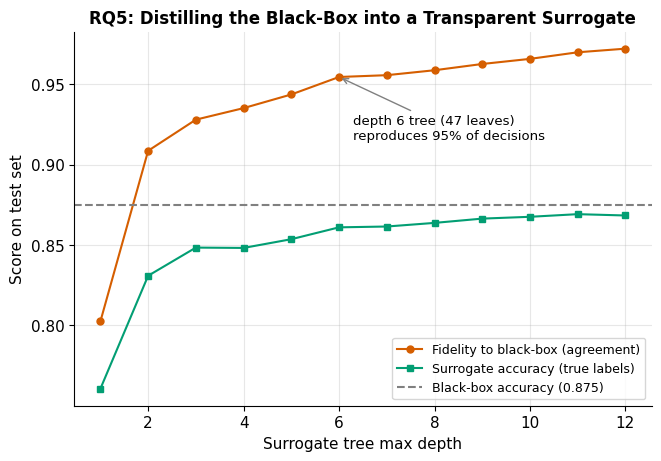

  saved figure: rq5_surrogate_distillation.pdf / .png


In [11]:
print("\nRQ5: surrogate distillation...")
teacher = fitted["Gradient Boosting"]
teacher_train = teacher.predict(X_train)
teacher_test = teacher.predict(X_test)
teacher_acc = accuracy_score(y_test, teacher_test)

rows = []
for d in range(1, 13):
    surr = make_pipe(DecisionTreeClassifier(max_depth=d, random_state=SEED))
    surr.fit(X_train, teacher_train)          # trained to mimic the teacher
    pred = surr.predict(X_test)
    rows.append({
        "max_depth": d,
        "n_leaves": int(surr.named_steps["model"].tree_.n_leaves),
        "fidelity_to_blackbox": accuracy_score(teacher_test, pred),
        "surrogate_test_accuracy": accuracy_score(y_test, pred),
        "teacher_test_accuracy": teacher_acc,
    })
rq5 = pd.DataFrame(rows)
save_table(rq5.round(4), "rq5_surrogate_distillation")
hi_fid = rq5[rq5["fidelity_to_blackbox"] >= 0.95].iloc[0] \
    if (rq5["fidelity_to_blackbox"] >= 0.95).any() else rq5.iloc[-1]
print(f"  depth {int(hi_fid['max_depth'])} surrogate reproduces "
      f"{hi_fid['fidelity_to_blackbox']:.1%} of black-box decisions")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(rq5["max_depth"], rq5["fidelity_to_blackbox"], "-o", color=C_GB,
        ms=5, label="Fidelity to black-box (agreement)")
ax.plot(rq5["max_depth"], rq5["surrogate_test_accuracy"], "-s", color=C_DT,
        ms=5, label="Surrogate accuracy (true labels)")
ax.axhline(teacher_acc, color="gray", ls="--", lw=1.5,
           label=f"Black-box accuracy ({teacher_acc:.3f})")
ax.annotate(f"depth {int(hi_fid['max_depth'])} tree "
            f"({int(hi_fid['n_leaves'])} leaves)\nreproduces "
            f"{hi_fid['fidelity_to_blackbox']:.0%} of decisions",
            (hi_fid["max_depth"], hi_fid["fidelity_to_blackbox"]),
            textcoords="offset points", xytext=(10, -45), fontsize=9.5,
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_xlabel("Surrogate tree max depth")
ax.set_ylabel("Score on test set")
ax.set_title("RQ5: Distilling the Black-Box into a Transparent Surrogate")
ax.legend(fontsize=9, loc="lower right")
save_fig(fig, "rq5_surrogate_distillation")

In [12]:
# RQ5 result table (saved as outputs/tables/rq5_surrogate_distillation.csv)
rq5.round(4)

,max_depth,n_leaves,fidelity_to_blackbox,surrogate_test_accuracy,teacher_test_accuracy
0,1,2,0.8025,0.7607,0.875
1,2,4,0.9086,0.8309,0.875
2,3,8,0.9279,0.8484,0.875
3,4,16,0.9351,0.8482,0.875
4,5,29,0.9436,0.8536,0.875
5,6,47,0.9544,0.8610,0.875
6,7,75,0.9556,0.8615,0.875
7,8,112,0.9586,0.8638,0.875
8,9,161,0.9625,0.8664,0.875
9,10,217,0.9657,0.8675,0.875


## Key findings summary

Writes the headline numbers of all five RQs to `outputs/key_findings.txt`.

In [13]:
dt4_auc = rq1.loc[rq1["model"] == "Decision Tree (depth 4)", "test_auc"].iloc[0]
gap_pp = (gb_auc - lr_auc) * 100
summary = f"""KEY NUMBERS (test set, seed={SEED})
RQ1  Gradient Boosting AUC {gb_auc:.4f} vs Logistic Regression {lr_auc:.4f}
     -> black-box advantage = {gap_pp:.2f} AUC points; depth-4 tree {dt4_auc:.4f}
RQ2  sweet spot at depth {int(sweet['max_depth'])} ({int(sweet['n_leaves'])} leaves),
     CV AUC {sweet['cv_auc_mean']:.4f} vs best tree {best:.4f}
RQ3  Spearman rank agreement between model explanations: rho = {rho:.3f}
RQ4  black-box advantage overall {overall_adv:.4f} AUC; per-group range
     {rq4.loc[rq4['attribute'] != 'overall', 'blackbox_advantage'].min():.4f} .. {rq4.loc[rq4['attribute'] != 'overall', 'blackbox_advantage'].max():.4f}
RQ5  depth-{int(hi_fid['max_depth'])} surrogate: fidelity {hi_fid['fidelity_to_blackbox']:.4f},
     accuracy {hi_fid['surrogate_test_accuracy']:.4f} (teacher {teacher_acc:.4f})
"""
with open(os.path.join("outputs", "key_findings.txt"), "w") as f:
    f.write(summary)
print("\n" + summary)
print("Done. All figures (PDF+PNG) and tables (CSV) are in outputs/.")


KEY NUMBERS (test set, seed=42)
RQ1  Gradient Boosting AUC 0.9297 vs Logistic Regression 0.9049
     -> black-box advantage = 2.48 AUC points; depth-4 tree 0.8743
RQ2  sweet spot at depth 8 (132 leaves),
     CV AUC 0.9018 vs best tree 0.9021
RQ3  Spearman rank agreement between model explanations: rho = 0.839
RQ4  black-box advantage overall 0.0248 AUC; per-group range
     0.0177 .. 0.0333
RQ5  depth-6 surrogate: fidelity 0.9544,
     accuracy 0.8610 (teacher 0.8750)

Done. All figures (PDF+PNG) and tables (CSV) are in outputs/.
